In [ ]:
# Install dependencies
!pip install kaggle torch torchvision pandas tqdm scikit-learn psutil

In [ ]:
# Download small NIH sample dataset (~100MB)
!wget -q https://github.com/mlmed/torchxrayvision/releases/download/v1/nih_sample.zip

# Unzip
!unzip -q nih_sample.zip

print("Download & extraction done ✅")

unzip:  cannot find or open nih_sample.zip, nih_sample.zip.zip or nih_sample.zip.ZIP.
Download & extraction done ✅


In [ ]:
!ls
!ls nih_sample

sample_data
ls: cannot access 'nih_sample': No such file or directory


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class SimpleXrayDataset(Dataset):
    def __init__(self, root_dir):
        self.root = root_dir

        if not os.path.exists(self.root):
            raise FileNotFoundError(f"Folder not found: {self.root}")

        self.files = [
            os.path.join(self.root, f)
            for f in os.listdir(self.root)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        if len(self.files) == 0:
            raise ValueError(f"No images found in {self.root}")

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])

        print(f"Loaded {len(self.files)} images")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]

        try:
            img = Image.open(img_path).convert("RGB")
        except:
            return self.__getitem__((idx + 1) % len(self.files))

        img = self.transform(img)

        # Fake labels for demo
        label = torch.randint(0, 2, (14,)).float()

        return img, label

In [ ]:
from torch.utils.data import DataLoader

dataset = SimpleXrayDataset("nih_sample/images")

loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset size:", len(dataset))

FileNotFoundError: Folder not found: nih_sample/images

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:40<00:00, 15.3MB/s]



In [ ]:
!unzip -q chest-xray-pneumonia.zip

In [ ]:
!ls chest_xray

chest_xray  __MACOSX  test  train  val


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class PneumoniaDataset(Dataset):
    def __init__(self, root_dir):
        self.files = []

        for label in ["NORMAL", "PNEUMONIA"]:
            path = os.path.join(root_dir, label)
            for f in os.listdir(path):
                if f.endswith((".jpeg", ".jpg", ".png")):
                    self.files.append((os.path.join(path, f), label))

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

        print(f"Loaded {len(self.files)} images")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path, label_name = self.files[idx]

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        # Convert to 14-dim fake label (to match your model)
        label = torch.zeros(14)
        if label_name == "PNEUMONIA":
            label[1] = 1  # just mark one disease

        return img, label

In [ ]:
dataset = PneumoniaDataset("chest_xray/train")

from torch.utils.data import DataLoader
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset size:", len(dataset))

Loaded 5216 images
Dataset size: 5216


In [ ]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, patch_size=16, dim=128):
        super().__init__()
        self.proj = nn.Conv2d(3, dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                  # (B, D, H, W)
        x = x.flatten(2).transpose(1,2)  # (B, N, D)
        return x

In [ ]:
import torch.nn.functional as F

def compute_similarity(tokens):
    # Feature similarity (cosine)
    tokens_norm = F.normalize(tokens, dim=-1)
    sim = torch.matmul(tokens_norm, tokens_norm.transpose(1,2))
    return sim

In [ ]:
def spatial_matrix(N):
    coords = torch.arange(N).unsqueeze(1)
    dist = torch.abs(coords - coords.T).float()
    spatial = torch.exp(-dist / N)
    return spatial

In [ ]:
def structural_matrix(tokens, alpha=0.7):
    B, N, D = tokens.shape

    sim = compute_similarity(tokens)              # feature similarity
    spatial = spatial_matrix(N).to(tokens.device) # spatial prior

    S = alpha * sim + (1 - alpha) * spatial

    return S

In [ ]:
def build_sparse_graph(S, k=10):
    topk_vals, topk_idx = torch.topk(S, k, dim=-1)

    mask = torch.zeros_like(S)
    mask.scatter_(-1, topk_idx, 1)

    sparse_S = S * mask

    return sparse_S

In [ ]:
import matplotlib.pyplot as plt

def plot_heatmap(matrix, title):
    plt.figure(figsize=(6,5))
    plt.imshow(matrix, cmap='hot')
    plt.colorbar()
    plt.title(title)
    plt.savefig(f"{title}.png")
    plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

patch = PatchEmbedding().to(device)

imgs, labels = next(iter(loader))
imgs = imgs.to(device)

tokens = patch(imgs)           # (B, N, D)

S = structural_matrix(tokens)  # full matrix
S_sparse = build_sparse_graph(S)

print("Tokens:", tokens.shape)
print("Similarity matrix:", S.shape)

Tokens: torch.Size([8, 196, 128])
Similarity matrix: torch.Size([8, 196, 196])


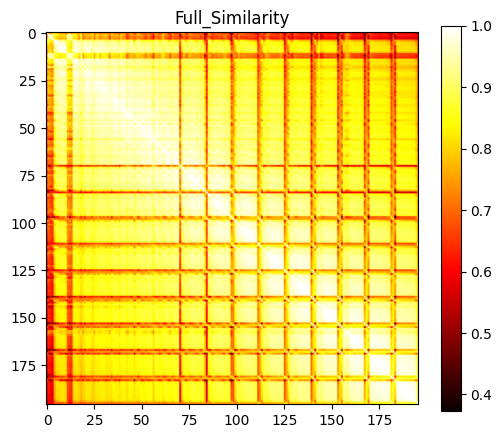

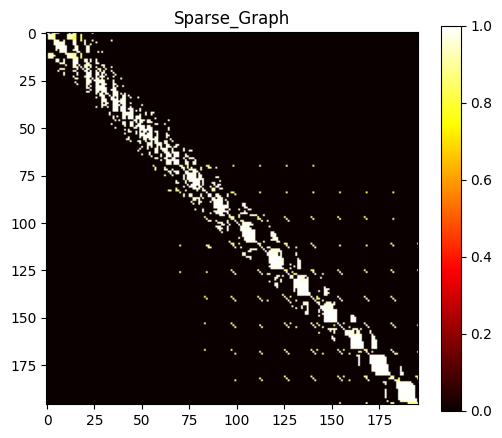

In [ ]:
plot_heatmap(S[0].detach().cpu(), "Full_Similarity")
plot_heatmap(S_sparse[0].detach().cpu(), "Sparse_Graph")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def compute_metrics(preds, labels):
    preds = (preds > 0.5).astype(int)
    labels = labels.astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average='micro'),
        "recall": recall_score(labels, preds, average='micro'),
        "f1": f1_score(labels, preds, average='micro')
    }

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PatchEmbedding(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.proj = nn.Conv2d(3, dim, kernel_size=16, stride=16)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)  # (B, N, D)
        return x

In [ ]:
def compute_similarity(tokens):
    tokens = F.normalize(tokens, dim=-1)
    return torch.matmul(tokens, tokens.transpose(1,2))


def spatial_matrix(N, device):
    coords = torch.arange(N, device=device).unsqueeze(1)
    dist = torch.abs(coords - coords.T).float()
    return torch.exp(-dist / N)


def structural_matrix(tokens, alpha=0.7):
    B, N, D = tokens.shape

    sim = compute_similarity(tokens)
    spatial = spatial_matrix(N, tokens.device)

    S = alpha * sim + (1 - alpha) * spatial
    return S

In [ ]:
def build_sparse_graph(S, k=10):
    topk_vals, topk_idx = torch.topk(S, k, dim=-1)

    mask = torch.zeros_like(S)
    mask.scatter_(-1, topk_idx, 1)

    return S * mask

In [ ]:
class StructuralAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x).chunk(3, dim=-1)
        q, k, v = qkv

        # ---- STANDARD ATTENTION ----
        attn = torch.matmul(q, k.transpose(1,2)) * self.scale

        # ---- STRUCTURAL PRIOR ----
        S = structural_matrix(x)
        S = build_sparse_graph(S)

        # 🔥 KEY IDEA: add structure as bias
        attn = attn + S

        attn = torch.softmax(attn, dim=-1)

        out = torch.matmul(attn, v)

        return self.proj(out)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = StructuralAttention(dim)

        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [ ]:
class SCViT(nn.Module):
    def __init__(self, dim=128, depth=4, num_classes=14):
        super().__init__()

        self.patch = PatchEmbedding(dim)

        self.cls = nn.Parameter(torch.randn(1,1,dim))
        self.pos = nn.Parameter(torch.randn(1,197,dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(dim) for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B = x.size(0)

        x = self.patch(x)

        cls = self.cls.expand(B,-1,-1)
        x = torch.cat([cls, x], dim=1)

        x = x + self.pos[:,:x.size(1)]

        # ---- ADAPTIVE REFINEMENT ----
        for blk in self.blocks:
            x = blk(x)   # structure updated each layer

        x = self.norm(x)

        return self.head(x[:,0])

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SCViT().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(2):
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        preds = model(imgs)

        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss/len(loader)}")

Epoch 0, Loss: 0.08518149775161517
Epoch 1, Loss: 0.0309569947135869


In [ ]:
model.eval()

imgs, labels = next(iter(loader))
imgs = imgs.to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(imgs))

print("Pred:", preds[0].cpu().numpy())
print("GT:", labels[0].numpy())

Pred: [0.00181732 0.9421882  0.00215755 0.00260022 0.00158073 0.00401529
 0.00210701 0.00250258 0.00250523 0.002403   0.00116223 0.00180855
 0.00231995 0.00203372]
GT: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

all_preds, all_labels = [], []

for imgs, labels in loader:
    imgs = imgs.to(device)

    with torch.no_grad():
        preds = torch.sigmoid(model(imgs)).cpu().numpy()

    all_preds.append(preds)
    all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

pred_bin = (all_preds > 0.5).astype(int)

print("Accuracy:", accuracy_score(all_labels, pred_bin))
print("Precision:", precision_score(all_labels, pred_bin, average='micro'))
print("Recall:", recall_score(all_labels, pred_bin, average='micro'))
print("F1:", f1_score(all_labels, pred_bin, average='micro'))

Accuracy: 0.8920628834355828
Precision: 0.9154540893125941
Recall: 0.9416774193548387
F1: 0.9283806131535428


In [ ]:
import matplotlib.pyplot as plt

def plot_heatmap(matrix, title="Heatmap"):
    plt.figure(figsize=(6,5))
    plt.imshow(matrix, cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Patches")
    plt.ylabel("Patches")
    plt.tight_layout()

    plt.savefig(f"{title}.png")  # save for report
    plt.show()

In [ ]:
# Take one batch
imgs, _ = next(iter(loader))
imgs = imgs.to(device)

# Get tokens
patch = PatchEmbedding().to(device)
tokens = patch(imgs)

# Compute structural matrix
S = structural_matrix(tokens)

# Convert to CPU numpy
S_np = S[0].detach().cpu().numpy()

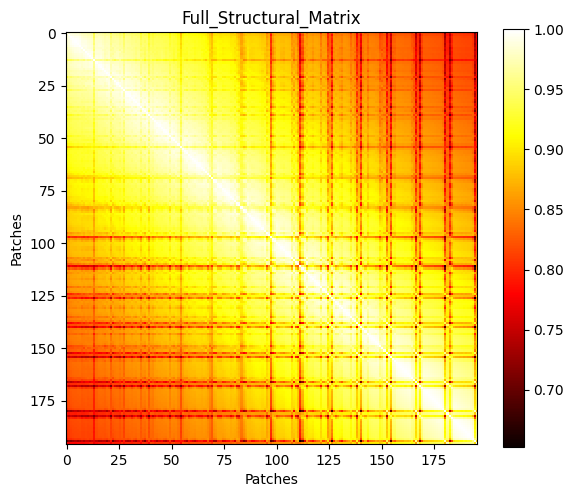

In [ ]:
plot_heatmap(S_np, "Full_Structural_Matrix")

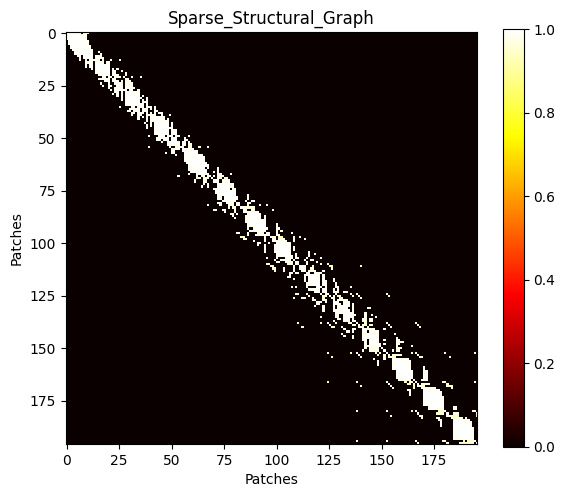

In [ ]:
S_sparse = build_sparse_graph(S)

S_sparse_np = S_sparse[0].detach().cpu().numpy()

plot_heatmap(S_sparse_np, "Sparse_Structural_Graph")

In [ ]:
import networkx as nx
import numpy as np

def plot_graph(matrix, title="Graph"):
    G = nx.Graph()
    N = matrix.shape[0]

    # Add nodes
    for i in range(N):
        G.add_node(i)

    # Add edges (only strong connections)
    threshold = np.mean(matrix)

    for i in range(N):
        for j in range(N):
            if matrix[i][j] > threshold:
                G.add_edge(i, j, weight=matrix[i][j])

    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_size=20, edge_color='gray', with_labels=False)

    plt.title(title)
    plt.savefig(f"{title}.png")
    plt.show()

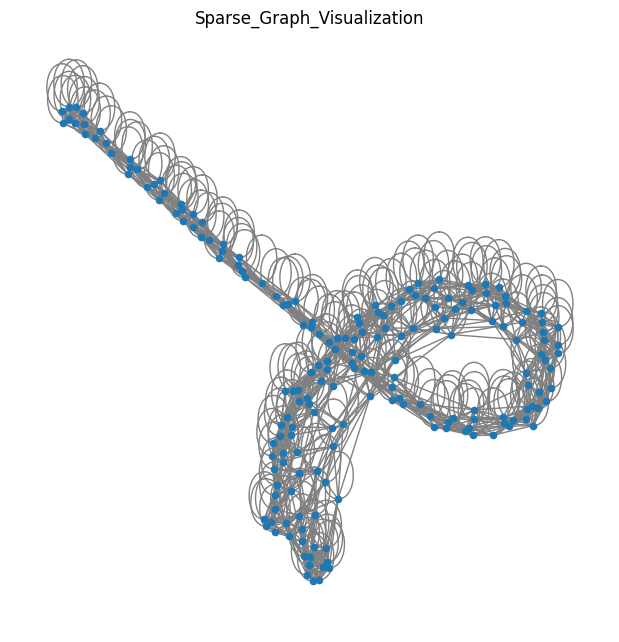

In [ ]:
plot_graph(S_sparse_np, "Sparse_Graph_Visualization")